- Watch AssemblyAI's from scratch series: [AssemblyAI's video](https://www.youtube.com/watch?v=p1hGz0w_OCo&list=PLcWfeUsAys2k_xub3mHks85sBHZvg24Jd) or [Github repo](https://github.com/AssemblyAI-Community/Machine-Learning-From-Scratch)

- There are words generated using 2.5 Flash, summarized and cleaned by human intended to be read by human to improve understanding.

In [1]:
# Install huggingface's dataset module
!pip install datasets

# Install data analysis module
!pip install statsmodels

# Instal plotting module
!pip install matplotlib
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
from collections import Counter

# Hugging face
from datasets import load_dataset

# Sklearn modules
from sklearn.datasets import load_iris, load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree # model
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # model
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
 

# Data analysis modules
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Plotter
from pandas.plotting import scatter_matrix
import seaborn as sns
import matplotlib.pyplot as plt 

/home/troll/miniconda3/envs/random/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Lesson: Basic Understanding of AI terms

- This notebook is made in mind that the reader has little knowledge regarding AI.
- This mini section should be understood in depth before continuing.
- Important understanding:
    - `feature` is the "what" - Example: What characteristics of this house? 
        - Long version: "Feature" can be Data points or characteristics of an object that help you describe it. They are **independent variables** in your dataset.
    - `label` is the "answer" - Example: What is its price. 
        - Long version: "Label" is the **Outcome** you are trying to predict. It is a dependent variable. 
    - Regression task.
        - A regression task predicts a continuous numerical value. The goal is to model the relationship between input features and a continuous output, allowing for a prediction within a range.
        - Output: A real number.
        - Examples: Predicting a house price (e.g., $450,000), a person's age (e.g., 34.5 years), or the temperature tomorrow (e.g., 22°C).
    - Classification task.
        - A classification task predicts a discrete category or class label. The goal is to sort data into predefined groups.
        - Output: A category.
        - Examples: Determining if an email is spam or not spam (binary classification), classifying a fruit as an apple, orange, or banana (multi-class classification), or identifying if a customer will churn or not churn.
- What is Mean Square Error (MSE)? 
    - TL;DR. For Regression Task. 
    - In decision tree, MSE is a splitting criterion used in regression decision trees. Regression trees are used to predict a continuous numerical value, like house prices or a person's age.
    - The goal is to choose the split that results in the lowest weighted average MSE for the child nodes. 
    - A lower MSE indicates that the data points within a node are closer to their mean, meaning the node is more "pure" in terms of its target values; **The lower the MSE, the better (closer to target)**.
        - At each step of building the tree, the algorithm considers different possible splits for a node. 
        - For each potential split, it calculates the MSE of the resulting child nodes. 
        - The MSE of a node is the average of the squared differences between the actual values and the predicted mean value of that node.
    - $MSE= \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$
        - $n$ is the number of data points in the node.
        - $yi$​ is the actual value of the i-th data point; Actual or Target value.
        - $y^​i$​ is the predicted mean value for all data points in that node; Predicted Value.
- What is Cross-Entropy Loss?
    - TL;DR. For Classification.
    - Cross-entropy is a metric used in classification decision trees to measure the impurity of a node.
    - It quantifies the difference between the actual class distribution in a node and a perfect distribution where all data points belong to a single class. 
    - Cross-entropy measures the "surprise" of a model's prediction.
    - The goal of a decision tree algorithm is to find the best feature to split a node, and it does so by selecting the split that results in the greatest reduction in cross-entropy. 
    - This reduction is often referred to as **Information Gain**.
    - $Cross - Entropy = -\sum_{k=1}^Cp_klog_2(p_k)$
        - $p_k​$ is the proportion of data points belonging to class $k$ within the node.
- What is Gini impurity?
    - TL;DR. For Classification.
    - Gini impurity is a splitting criterion used in classification decision trees. 
        - These trees predict a categorical outcome, such as whether an email is spam or not, or if a customer will churn.
    - Gini impurity measures the "impurity" or disorder of a node. 
        - It quantifies the probability that a randomly chosen data point from the node would be incorrectly classified if you were to randomly assign a class label based on the class distribution in that node. 
        - A Gini impurity of 0 means the node is perfectly pure (all data points belong to the same class), while a higher value indicates a mix of classes; **Close to 0 = Pure**.
    - The decision tree algorithm calculates the Gini impurity for each potential split and chooses the split that leads to the **greatest reduction in impurity** (or the lowest weighted average Gini impurity for the child nodes).
    - $Gini=1-\sum_{i=1}^C(p^2_k)$
        - $p_k$​ is the proportion of data points belonging to class $k$ within the node.

More Information
- Cross-Entropy Loss vs Gini
    - **Computation**: Cross-entropy uses a _logarithm_, which is slightly more computationally intensive than Gini impurity's squaring operation.
    - **Maximum Value**: For a binary classification problem, Gini impurity has a maximum value of 0.5, while cross-entropy (or entropy) has a maximum of 1.
    - **Penalty**: Both metrics penalize impurity. Cross-entropy tends to penalize confident but incorrect predictions more heavily than Gini impurity.
- What happens if you use MSE on a classification task?
    - **Inappropriate Assumptions**: MSE assumes that the output values are continuous and have a Gaussian distribution, which is not the case for classification task where the outputs are distinct (or a percentage of; 90% dog, 10% cat).
    - **Weak Penalty for Misclassification**: MSE penalizes errors based on the squared distance between the predicted value and the target value. 
        - For classification, the target values are typically 0 or 1. If a model predicts a probability of 0.94 for a class that is actually 1, the MSE loss is a small (1−0.94)2=0.0036.
        - However, if it predicts 0.49 for the same class (which is technically a misclassification if the threshold is 0.5), the MSE is still small, (1−0.49)2=0.26.
    - **Non-Convexity**: The primary issue is that using MSE with a classification model like logistic regression can lead to a non-convex loss function. 
        - A non-convex function has multiple "dips" or local minima, making it difficult for optimization algorithms (like gradient descent) to find the best possible solution. 
        - The model can get stuck in a local minimum and fail to converge to the optimal set of parameters.

---
# Decision Tree

- A flowchart-like structure used in machine learning for both classification and regression tasks. 
- It breaks down complex decisions into a series of simpler questions, making it easy to understand and interpret.
- Key components:
    - Root Node: This is the starting point of the tree, representing the entire dataset or the initial decision to be made.
    - Branches: These represent the possible outcomes or answers to a question at a decision node.
    - Internal Nodes (Decision Nodes): At these nodes, a test or question is performed on a specific feature of the data. Based on the answer, the tree follows a particular branch.
    - Leaf Nodes (Terminal Nodes): These are the endpoints of the tree, representing the final decision, prediction, or classification.

# Decision Tree for Classification



- Let's understand Decision Tree from Classification perspective first.
- We will use the [Iris dataset](https://huggingface.co/datasets/scikit-learn/iris) for a simplified study of Decision Tree.
- We will use the [Wine dataset](https://huggingface.co/datasets/lvwerra/red-wine) as a more complex dataset.

## 1. Iris Dataset (Simple)

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  v

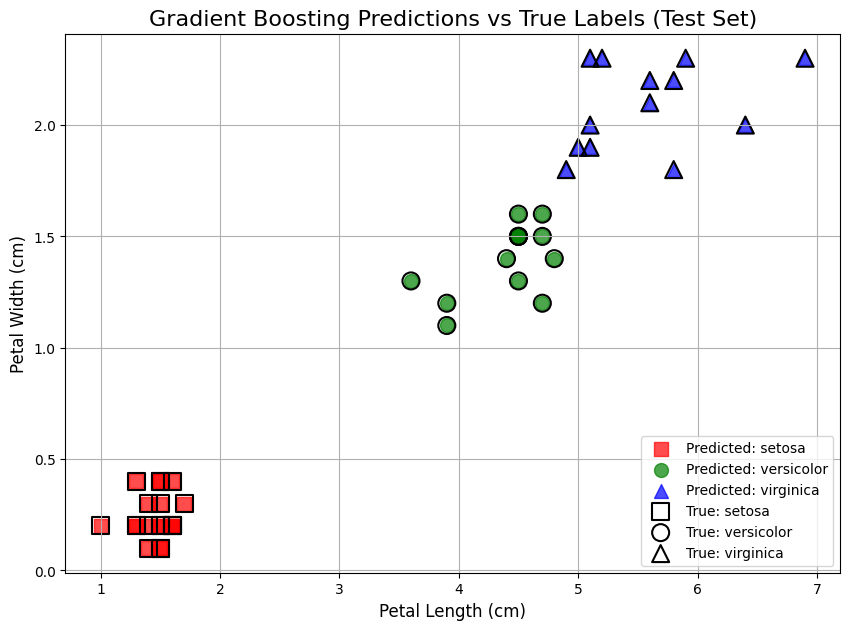

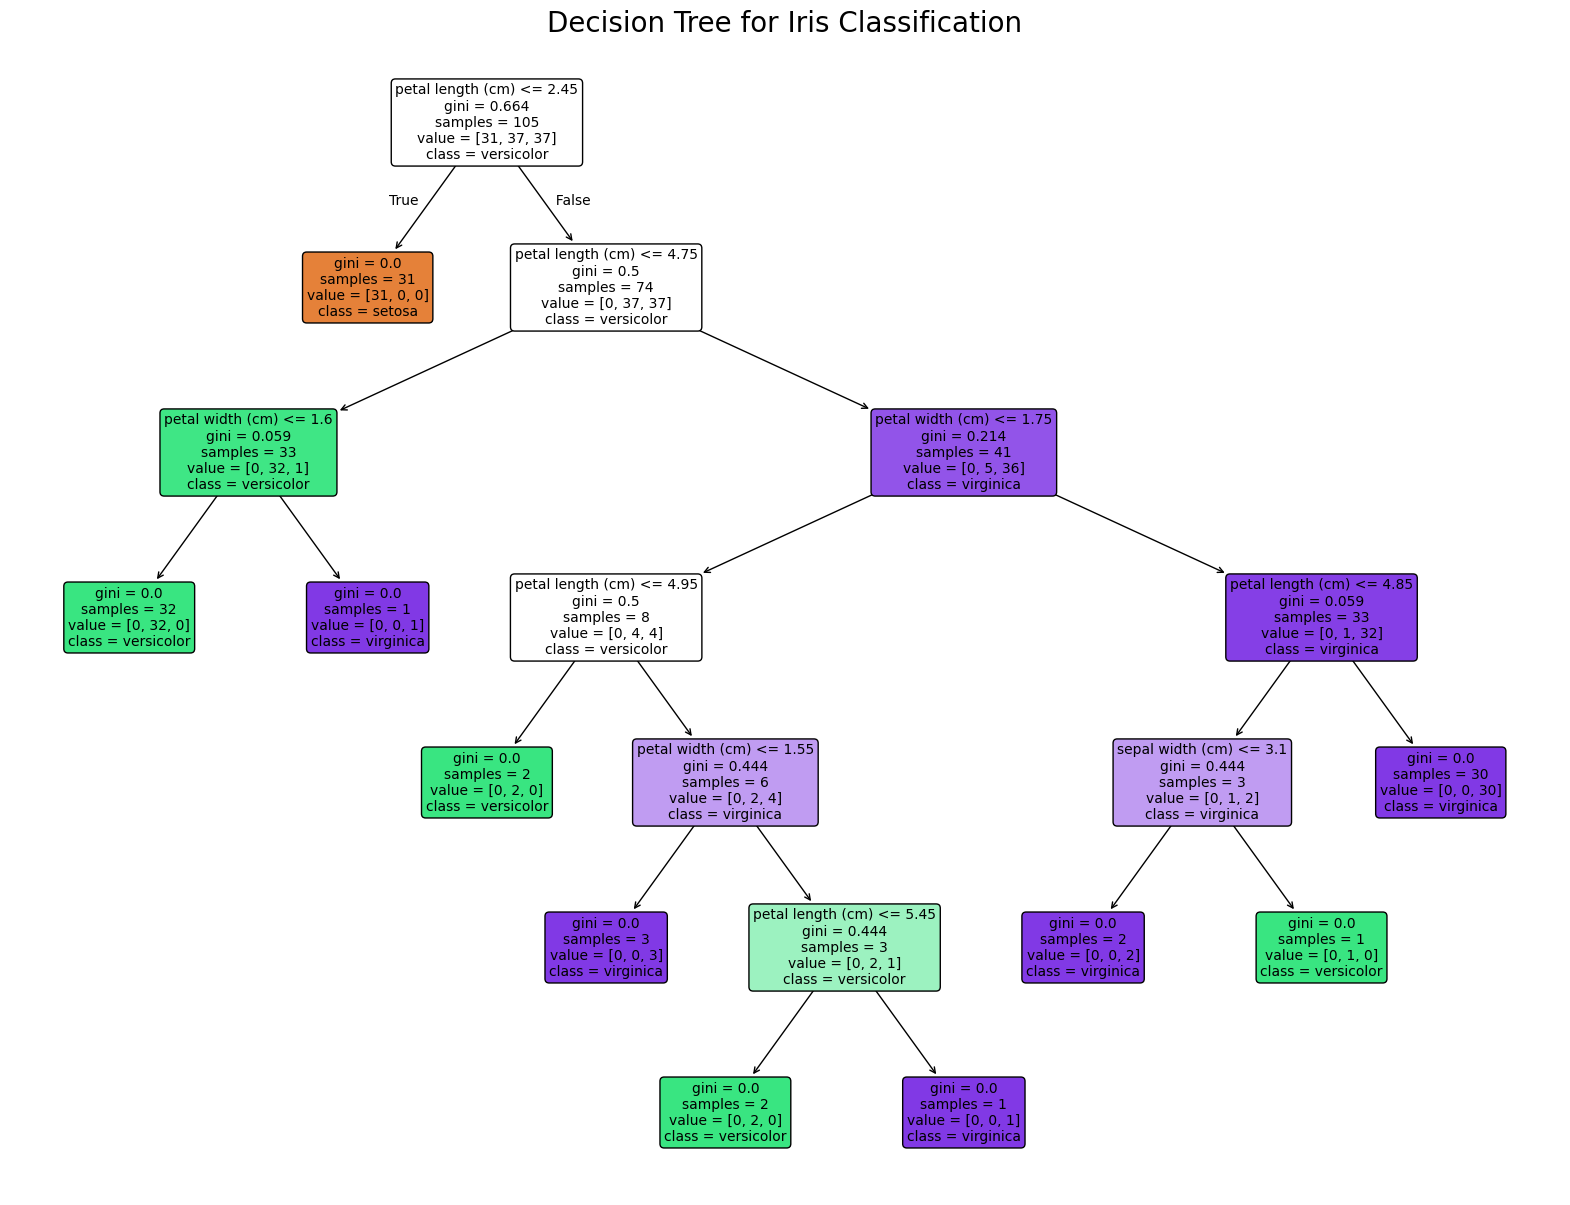

In [3]:
# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names


# Create a DataFrame using the data and feature names
df = pd.DataFrame(data=iris.data, columns=iris.feature_names) 
print(df.describe())

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4]

# --- Model Building ---
# Initialize and train a single Gradient Boosting model on all four features.
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train) 

# Make predictions on the test set (using all four features)
y_pred = model.predict(X_test)

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# --- Plot ---
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors and markers for each class
colors = ['red', 'green', 'blue']
markers = ['s', 'o', '^']
class_labels = iris.target_names

# Plot the predicted classes with solid colors
for i, (target_name, color) in enumerate(zip(class_labels, colors)):
    ax.scatter(X_test_plot[y_pred == i, 0], X_test_plot[y_pred == i, 1],
               c=color, label=f'Predicted: {target_name}', marker=markers[i],
               s=100, alpha=0.7)

# Plot the true classes with outlines/different markers to compare
for i, (target_name, marker) in enumerate(zip(class_labels, markers)):
    ax.scatter(X_test_plot[y_test == i, 0], X_test_plot[y_test == i, 1],
               edgecolor='black', facecolors='none', marker=marker, s=150,
               linewidth=1.5, label=f'True: {target_name}')

# Add plot labels and title
ax.set_title('Gradient Boosting Predictions vs True Labels (Test Set)', fontsize=16)
ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True)
plt.show()

# --- Plot tree ---
plt.figure(figsize=(20, 15))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Iris Classification", fontsize=20)
plt.show()

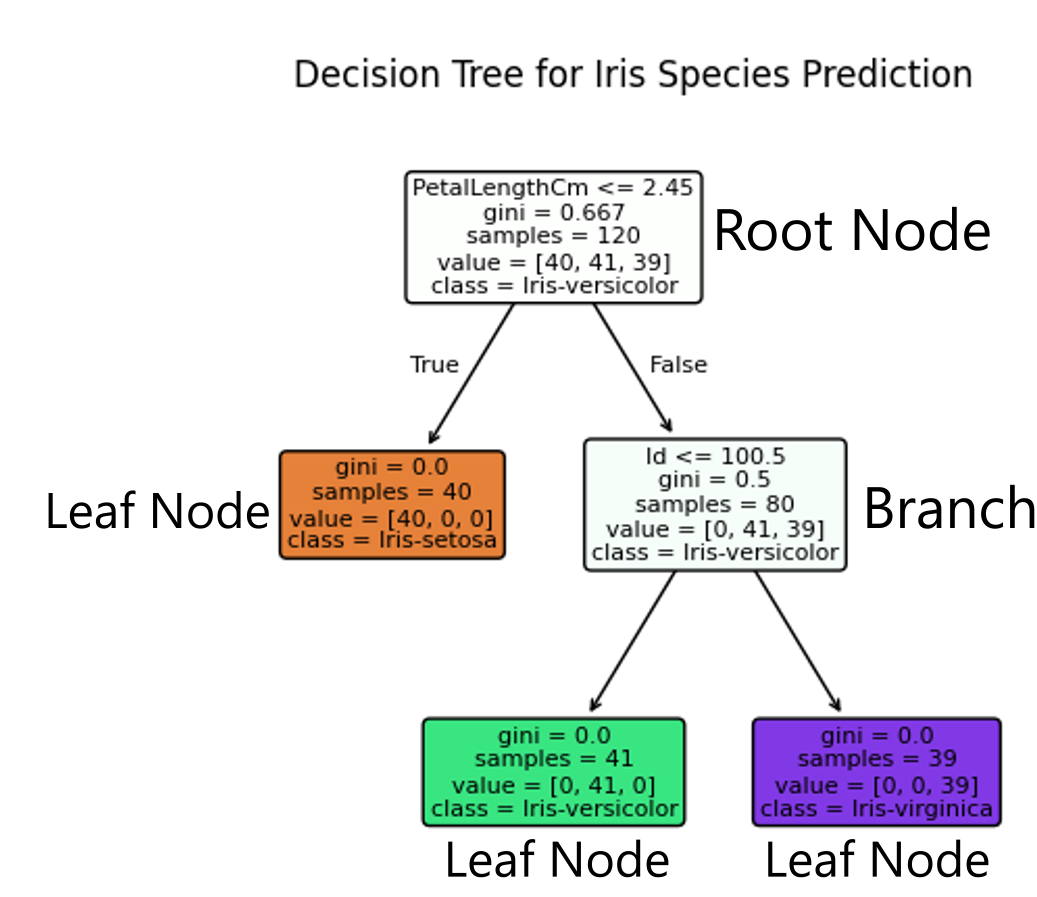

- The Root Node:
    - The process begins with all of your data at the top, or root node, of the tree. The algorithm then evaluates each column (e.g., petal length, petal width) to determine which one is the best at splitting the data into distinct groups. 
    - It does this using a statistical measure, such as Gini impurity or information gain, to find the feature that creates the purest, or most homogeneous, subsets.

- Internal Nodes/Branch (Decision Points): 
    - Once the best feature is found, the data is split based on a specific value of that feature. For example, the tree might split the iris data based on Id <= 100.5. The two resulting branches become new internal nodes, each containing a subset of the original data. This process of selecting the best feature and splitting the data is repeated at each new node.

- Leaf Nodes (Final Predictions): 
    - This recursive splitting continues until the algorithm reaches a point where further splitting doesn't significantly improve the purity of the data, or a predefined condition is met (like a maximum tree depth). The final nodes at the end of the branches are called leaf nodes, and they represent the predicted outcome, such as "Iris-setosa", "Iris-versicolor" and "Iris-virginica" for the Irises.

In essence, a decision tree visually maps out a path of logical questions (Is petal length in cm <=> 2.45?) that leads to a conclusion (This is likely a Iris-setosa.).

-.-.-.-.-.-.-.-.-.-.-
- Starting at the root node (top box), the first decision is 
    - `Petal length (in cm)` is <= (less than or equal to) 2.45,
        - If yes, go to left node (leaf node), other wise go to right node (branch)
    - This node has `gini` impurity of 0.667. Gini of 0 means the node is pure. 0.667 is high, indicating a mix of species.
    - `value` = [40, 41, 39]. This is the distribution of samples among the three classes. There are 40 samples of the first class, 41 of the second, and 39 of the third.
    - `class = Iris-versicolor`: The majority class at this node.
- Right (False) has another split of values of 41 and 39 for different classes (`Species`)

--- 

## 2. Breast Cancer Dataset (sklearn) - Prebuild & Custom (From Scratch)

### Using sklearn's model

Validation Accuracy: 0.88
Test Accuracy: 0.89


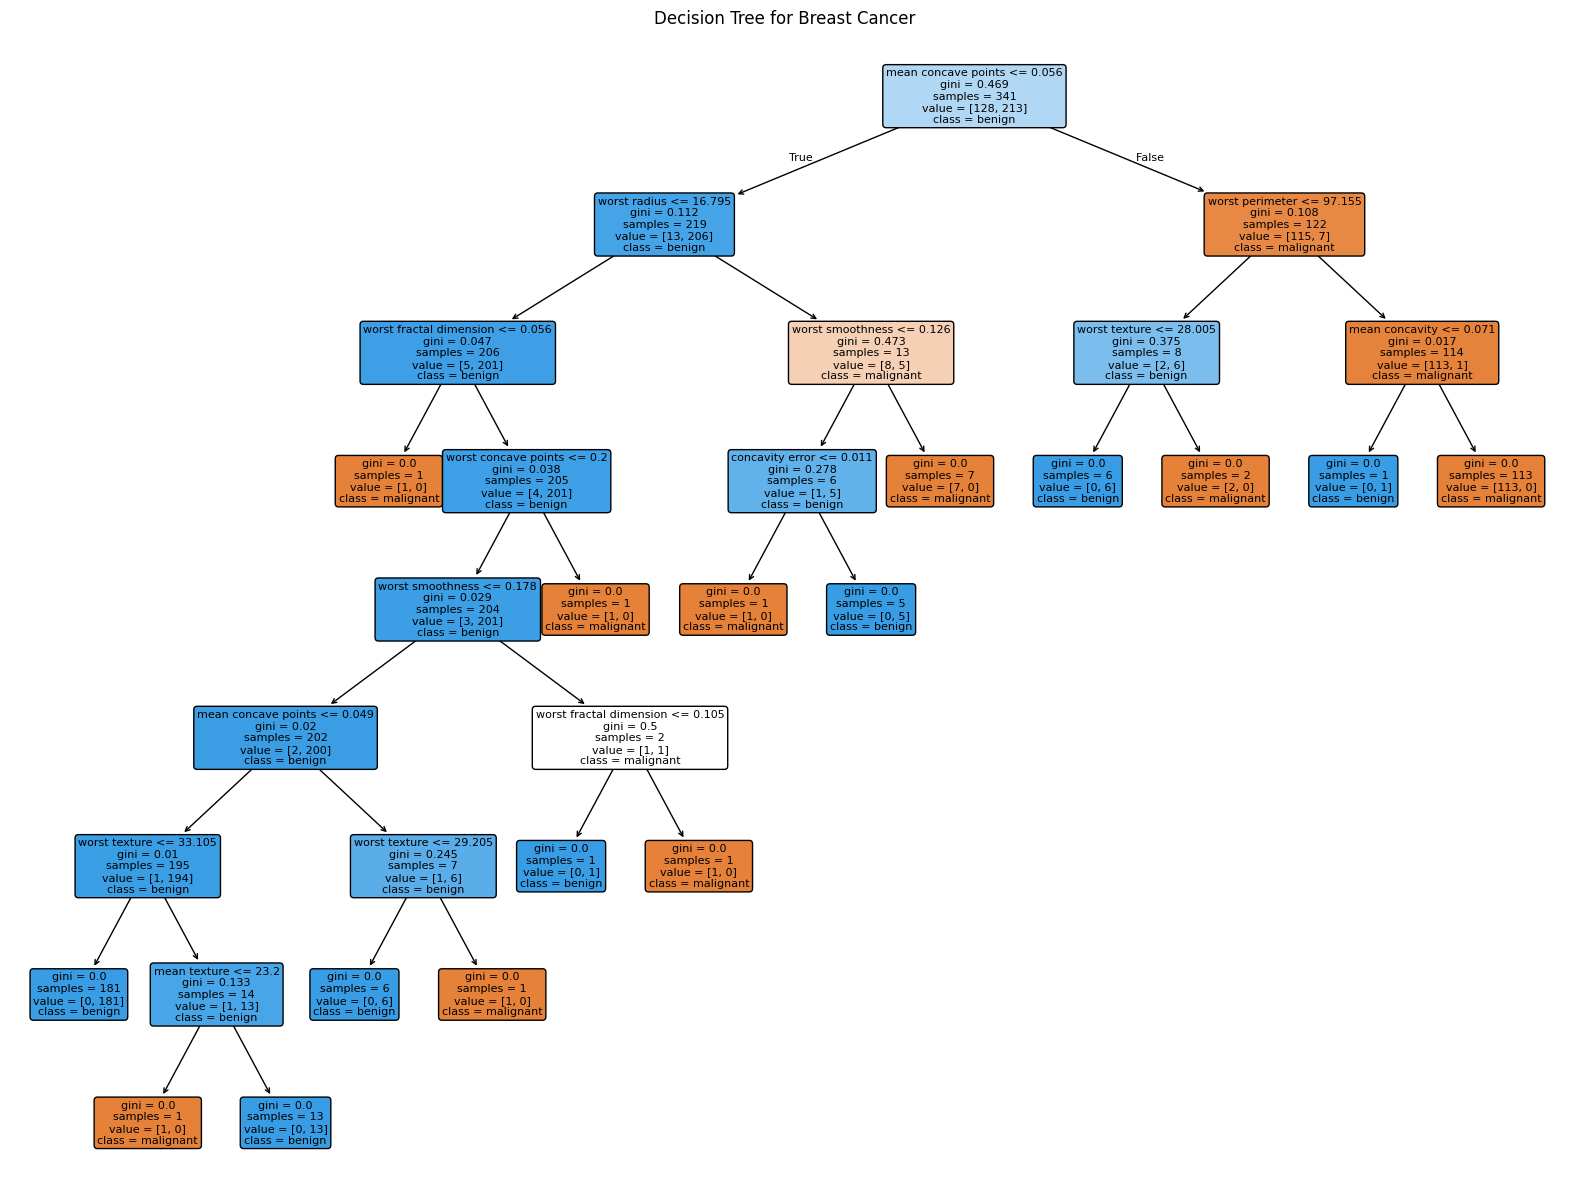

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
 
# Split the data into 60% training and 40% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)

# Split the temporary data into 50% validation and 50% testing
# This results in a 20% validation set and 20% test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# Initialize and train the Decision Tree model on the training data
model = DecisionTreeClassifier(random_state=1234)
model.fit(X_train, y_train)

# Evaluate the model on the validation set
val_predictions = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {val_accuracy:.2f}")

# Evaluate the model on the final, unseen test set
test_predictions = model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Visualize the Decision Tree
plt.figure(figsize=(20, 15))
plot_tree(model, 
          feature_names=data.feature_names,  
          class_names=data.target_names,
          filled=True, 
          rounded=True, 
          fontsize=8)
plt.title("Decision Tree for Breast Cancer")
plt.show()

- Root note condition: Worst concave points <= 0.142
- Internal Nodes: These nodes represent decision points, where a feature is tested.
- Leaf Nodes: These are the terminal nodes of the tree. They represent the final classification (benign or malignant) and provide information about the data that reached that node, including:
    - gini: The Gini impurity, a measure of how "mixed" the classes are at that node. A Gini of 0.0 indicates a pure node (all samples belong to one class).
    - samples: The number of data samples that reached this node.
    - value: The distribution of classes within those samples (Example: [152, 0] might mean 152 samples of one class and 0 of the other).

### Custom (from scratch) model
- The purpose of this subtopic is to look at the inner workings of the decision tree after you have understood its output (the tree plots).

In [5]:
# The Node class represents a single node in the decision tree.
# It can be either an internal node (decision node) or a leaf node.
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        # The index of the feature used for splitting at this node.
        # It's None for a leaf node.
        self.feature_index = feature_index
        # The threshold value used to split the data.
        # Data points with feature_index <= threshold go to the left child.
        self.threshold = threshold
        # A reference to the left child node.
        self.left = left
        # A reference to the right child node.
        self.right = right
        # The class label if this is a leaf node.
        # It's None for an internal node.
        self.value = value

# The CustomDecisionTreeClassifier class implements the decision tree algorithm.
class CustomDecisionTreeClassifier:
    def __init__(self, max_depth=5):
        # Maximum depth of the tree to prevent overfitting.
        self.max_depth = max_depth
        # The root node of the decision tree. It will be built during the training (fit) process.
        self.root = None

    # Private function calculates the Gini impurity of a set of class labels.
    # Gini impurity measures the "purity" of a node. A value of 0 means the node is perfectly pure (all labels are the same).
    def _calculate_gini_impurity(self, y):
        # Get the unique class labels in the current subset of data.
        class_labels = np.unique(y)
        gini = 0
        # Iterate over each unique class.
        for cls in class_labels:
            # Calculate the proportion of data points belonging to the current class.
            p_cls = len(y[y == cls]) / len(y)
            # Add the squared proportion to the sum.
            gini += p_cls * p_cls
        # The Gini impurity is 1 minus the sum of squared proportions.
        # Check the formula!
        return 1 - gini

    # Private function finds the best split for the data by iterating through features and thresholds.
    def _find_best_split(self, X, y, feature_indices):
        best_gini = 1  # Initialize with the highest possible Gini impurity.
        best_split = None
        # Iterate over a random subset of feature indices.
        for feature_index in feature_indices:
            # Get the unique values of the current feature to use as potential thresholds.
            thresholds = np.unique(X[:, feature_index])
            # Iterate over the each unique feature to find the threshold based on gini.
            for threshold in thresholds:
                # Split the data into two subsets based on the current threshold.
                y_left = y[X[:, feature_index] <= threshold]
                y_right = y[X[:, feature_index] > threshold]
                
                # If one of the subsets is empty, this is not a valid split.
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                
                # Calculate the Gini impurity for both subsets.
                gini_left = self._calculate_gini_impurity(y_left)
                gini_right = self._calculate_gini_impurity(y_right)
                
                # Calculate the weighted Gini impurity for the split.
                # This is the weighted average of the Gini impurities of the two child nodes.
                weighted_gini = (len(y_left) / len(y)) * gini_left + (len(y_right) / len(y)) * gini_right
                
                # If this split is better (has a lower weighted Gini), update the best split.
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_split = {'feature_index': feature_index, 'threshold': threshold}
        return best_split

    # Recursive function that builds the decision tree.
    def _grow_tree(self, X, y, depth=0):
        # Base case 1: All data points in the subset belong to the same class.
        # Base case 2: The maximum tree depth has been reached.
        # Base case 3: The number of data points is too small to split further.
        if len(np.unique(y)) == 1 or depth == self.max_depth or len(y) < 2:
            # Determine the most common class to use as the prediction for this leaf node.
            leaf_value = Counter(y).most_common(1)[0][0]
            # Return a new Node representing a leaf.
            return Node(value=leaf_value)
        
        # Get the number of features.
        n_features = X.shape[1]
        # Randomly select a subset of features to consider for the split.
        feature_indices = np.random.choice(n_features, int(np.sqrt(n_features)), replace=False)
        
        # Find the best split based on the selected features.
        best_split = self._find_best_split(X, y, feature_indices)
        
        # If no good split is found (e.g., all samples are identical), create a leaf node.
        if not best_split:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)
            
        # Get the indices of data points for the left and right splits.
        left_indices = X[:, best_split['feature_index']] <= best_split['threshold']
        right_indices = X[:, best_split['feature_index']] > best_split['threshold']
        
        # Recursively build the left and right subtrees.
        left_child = self._grow_tree(X[left_indices], y[left_indices], depth + 1)
        right_child = self._grow_tree(X[right_indices], y[right_indices], depth + 1)
        
        # Return a new Node for the current split.
        return Node(best_split['feature_index'], best_split['threshold'], left_child, right_child)

    # Private recursive function predicts the class for a single data point.
    def _predict_tree(self, x, node):
        # Base case: If the current node is a leaf, return its value.
        if node.value is not None:
            return node.value
        
        # If the feature value of the data point is less than or equal to the threshold,
        # traverse the left child.
        if x[node.feature_index] <= node.threshold:
            return self._predict_tree(x, node.left)
        # Otherwise, traverse the right child.
        return self._predict_tree(x, node.right)

    # Public function trains the decision tree model.
    def fit(self, X, y):
        # Start the recursive tree-building process from the root.
        self.root = self._grow_tree(X, y)

    # Public function predicts the class labels for a dataset.
    def predict(self, X):
        # For each data point in X, traverse the tree to get a prediction.
        return np.array([self._predict_tree(x, self.root) for x in X])

In [6]:
# Running the model
# Initialize and train the Decision Tree model
model = CustomDecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

# Evaluate the model (optional, but good practice)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
accuracy = np.sum(y_test == predictions) / len(y_test)
print(f"Model Accuracy: {accuracy:.2f}")

# Visualize the Decision Tree
def print_tree(node, depth=0):
    # If the node is a leaf, print its predicted value
    if node.value is not None:
        print(" " * depth * 2 + f"Predict: {node.value}")
    # If it's an internal node, print the split condition and recurse
    else:
        print(" " * depth * 2 + f"Feature {node.feature_index} <= {node.threshold:.2f}?")
        print(" " * depth * 2 + "├── True:")
        print_tree(node.left, depth + 1)
        print(" " * depth * 2 + "└── False:")
        print_tree(node.right, depth + 1)

# Visualize the custom tree
print("\nDecision Tree Structure:")
print_tree(model.root)

Model Accuracy: 0.93

Decision Tree Structure:
Feature 27 <= 0.15?
├── True:
  Feature 12 <= 4.09?
  ├── True:
    Feature 0 <= 15.00?
    ├── True:
      Feature 6 <= 0.10?
      ├── True:
        Feature 21 <= 32.84?
        ├── True:
          Predict: 1
        └── False:
          Predict: 1
      └── False:
        Feature 22 <= 100.90?
        ├── True:
          Predict: 1
        └── False:
          Predict: 0
    └── False:
      Feature 4 <= 0.08?
      ├── True:
        Predict: 1
      └── False:
        Feature 23 <= 947.90?
        ├── True:
          Predict: 1
        └── False:
          Predict: 0
  └── False:
    Feature 7 <= 0.03?
    ├── True:
      Predict: 1
    └── False:
      Predict: 0
└── False:
  Feature 4 <= 0.09?
  ├── True:
    Feature 13 <= 24.87?
    ├── True:
      Predict: 1
    └── False:
      Predict: 0
  └── False:
    Feature 22 <= 96.66?
    ├── True:
      Feature 18 <= 0.02?
      ├── True:
        Predict: 0
      └── False:
        Predic

---
## 3. Wine Dataset (Complex)
- Now let us look at a more complex dataset, the [Wine dataset](https://huggingface.co/datasets/lvwerra/red-wine).
- This is a segwey to introduce more complex model.

In [7]:
ds = load_dataset("lvwerra/red-wine")

train = ds['train']

df = train.to_pandas()

# Separate features and the target variable
features = df.drop('quality', axis=1)
target = df['quality']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(df.info())
print('-'*50)
print(df.describe())

Repo card metadata block was not found. Setting CardData to empty.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
--------------------------------------------------
       fixed acidity  volatile acidity  citric acid  residual sugar  \

In [8]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Explanation
- From the tables above, we can see that `quality` is an int and that it is between 3 to 8. 
    - We can use this as the `label` (Target) for our dataset.

- The following is an example visual of what a single Decision Tree may look like, 

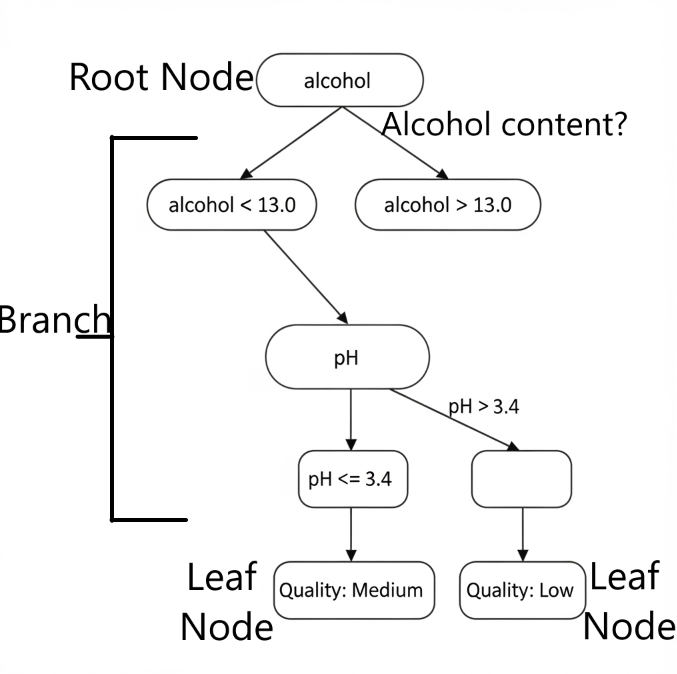

- The Root Node:
    - The process begins with all of your data at the top, or root node, of the tree. The algorithm then evaluates each column (e.g., alcohol content, pH, fixed acidity) to determine which one is the best at splitting the data into distinct groups. 
    - It does this using a statistical measure, such as Gini impurity or information gain, to find the feature that creates the purest, or most homogeneous, subsets.

- Internal Nodes (Decision Points): 
    - Once the best feature is found, the data is split based on a specific value of that feature. For example, the tree might split the wine data based on alcohol <= 13.0. The two resulting branches become new internal nodes, each containing a subset of the original data. This process of selecting the best feature and splitting the data is repeated at each new node.

- Leaf Nodes (Final Predictions): 
    - This recursive splitting continues until the algorithm reaches a point where further splitting doesn't significantly improve the purity of the data, or a predefined condition is met (like a maximum tree depth). The final nodes at the end of the branches are called leaf nodes, and they represent the predicted outcome, such as "High Quality," "Medium Quality," or "Low Quality" for the wine.

In essence, a decision tree visually maps out a path of logical questions (Is fixed acidity > 7.0?) that leads to a conclusion (This is likely a high-quality wine.).

## 1. Data Analysis 

- Before we continue, let's perform the usual data analysis. 

### Analysing General Pattern: Histogram

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

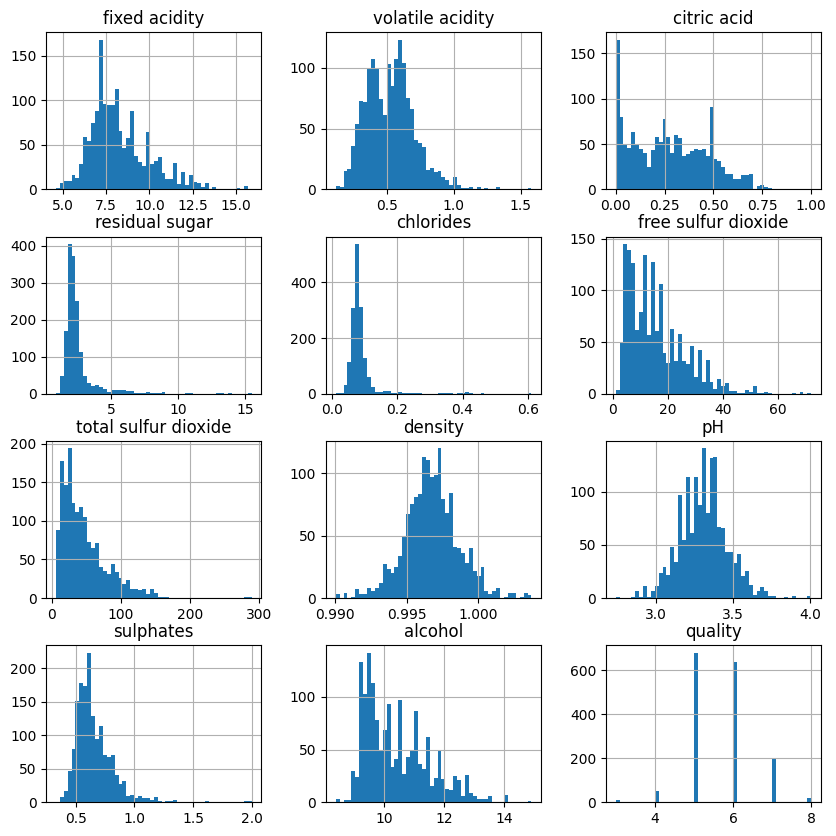

In [9]:
df.hist(bins=50, figsize=(10, 10))

Reading the histogram, Feature Distributions:

1. The histograms show the distribution of each feature.
    - Symmetrical (Normal-like) Distribution: `fixed acidity`, `pH`, `sulphates`, and `alcohol` appear to have a somewhat normal or bell-shaped distribution. 
        - This is ideal for some machine learning models that assume data is normally distributed.
    - Skewed Distribution: Most of the features are right-skewed (positively skewed), meaning their tail extends to the right. This is evident in `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, and `density`. 
        - This indicates that most of the wines have low values for these features, with a few having very high values.
    - ⚠️ Highly Skewed Distribution: `chlorides`, `residual sugar`, `total sulfur dioxide`, and `free sulfur dioxide` show a very strong positive skew. Most of the data is clustered at the low end of the range.
    - ⚠️ Bimodal Distribution: `citric acid` appears to have a bimodal distribution, with two distinct peaks. 
        - This suggests there might be <u>two different sub-groups of wines with differing citric acid levels</u>.

2. Outlier Detection 
    - The long tails in the skewed histograms, especially for features like `chlorides`, `residual sugar`, `total sulfur dioxide`, and `free sulfur dioxide`, are strong indicators of potential outliers. These are wines with exceptionally high values for these attributes.

3. Target Variable (quality)
- The quality histogram shows the distribution of the target variable.
- ⚠️ The most common quality ratings are 5 and 6. 
    - ⚠️ This tells us that the dataset is imbalanced, with a large majority of the wines receiving these two ratings.
    - Quality ratings of 3, 4, 7, and 8 are much less frequent. The quality ratings of 3 and 8 are particularly rare. This imbalance is a crucial factor to consider when training a machine learning model, as it <u>might become biased toward predicting the majority classes (5 and 6) and perform poorly on the less common classes</u>.



### Analysing Multicollinearity: Correlation Matrix and Variance Inflation Factor (VIF)

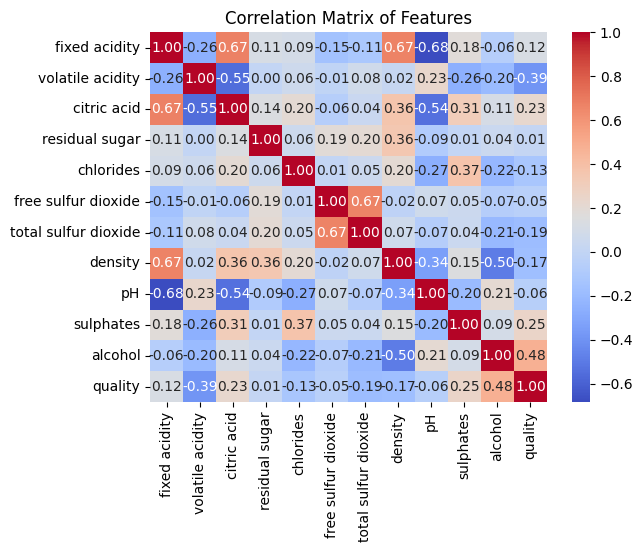

In [10]:
# Correlation Matrix
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

- Key Inferences from This Matrix
    - `quality` is most influenced by `alcohol` and `volatile acidity`
        - `alcohol` has the strongest positive correlation with quality (0.48), 
        - `volatile acidity` has the strongest negative correlation (-0.39). 
        - This suggests these two features are among the most important factors for predicting wine quality.

    - Strong feature-to-feature relationships:
        - `fixed acidity` has a strong positive correlation with `citric acid` (+0.67) and `density` (+0.67), but a strong negative correlation with `pH` (-0.68).
        - `free sulfur dioxide` and `total sulfur dioxide` are highly correlated (+0.67).
        - ⚠️ These pairs suggest significant multicollinearity. 

- This matrix is a crucial first step in feature selection, helping you identify which features are most likely to be good predictors and which might be redundant.

### Lesson: Multicollinearity
- Multicollinearity is a statistical phenomenon in which two or more predictor variables in a regression model are highly correlated with one another. 
- This strong correlation makes it difficult for the model to determine the individual effect of each predictor on the response variable, as they are essentially conveying the same information.
- There are two main types of multicollinearity:
    - Perfect Multicollinearity: 
        - This is the most extreme case, where one predictor variable is an exact linear combination of one or more other predictor variables. 
        - Example: if you include both a person's height in inches and their height in centimeters in the same model, you have perfect multicollinearity. In this scenario, the regression model's coefficients are not uniquely defined, and the software will often fail to run.

    - High (or Imperfect) Multicollinearity: 
        - This is the more common type, where predictor variables are highly correlated but not perfectly so. The model can still be estimated, but the results are unreliable and unstable. This is the issue most people refer to when they talk about multicollinearity.
        - Example: You are trying to build a regression model to predict house price. You included these two predictor variables, Square footage of the living area (X1​) Number of bedrooms (X2​). When you think about relationship between living area and number of bedroom, generally _the larger the house tend to have more bedrooms_. So, X1 and X2 are **highly likely to be correlated**. 
            - They may not perfectly correlated. Example you can have a house with a large living area and only two bedrooms, or a small apartment with a unique three-bedroom layout; but there is a very strong positive relationship. This high correlation between your two predictors is imperfect multicollinearity.

How to address Multicollinearity?
- One should address multicollinearity if possible, as it will affect the ability to interpret the individual contributions of the correlated variables.
- Remove a variable.
- Combine Variables (Example techniques: Average of features, Principal Component Analysis (PCA))
- Increase sample size.
- Use regularization techniques (Example: Ridge Regression, Lasso Regression - adds penalty term to the model, which shrinks the coefficient estimates and make them more stable).

In [11]:
# Variance Inflation Factor (VIF)
# predictor_cols = [
#     'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
#     'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
#     'pH', 'sulphates', 'alcohol'
# ]
predictor_cols = [col for col in df.columns if col != 'quality']

# Create a new DataFrame with the predictor columns
X = df[predictor_cols]

# Add a constant (intercept) to the DataFrame, which is required for VIF
# The intercept column is automatically named 'const'
X = add_constant(X)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# The VIF is calculated for each variable individually
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Print the VIF values, sorted in descending order
print(vif_data.sort_values(by="VIF", ascending=False))

                 feature           VIF
0                  const  1.710538e+06
1          fixed acidity  7.767512e+00
8                density  6.343760e+00
9                     pH  3.329732e+00
3            citric acid  3.128022e+00
11               alcohol  3.031160e+00
7   total sulfur dioxide  2.186813e+00
6    free sulfur dioxide  1.963019e+00
2       volatile acidity  1.789390e+00
4         residual sugar  1.702588e+00
5              chlorides  1.481932e+00
10             sulphates  1.429434e+00


- High Multicollinearity: The const (intercept), fixed acidity, and density variables show signs of multicollinearity.
    - The VIF for `fixed acidity` is 7.77, which is above the common threshold of 5. This suggests that fixed acidity is highly correlated with one or more other predictor variables in your model.
    - Similarly, the VIF for `density` is 6.34, also indicating a high level of correlation with other predictors.
- Other
    - `pH` (3.33) and `citric acid` (3.13) have VIFs slightly above 3, which is a good range, but still worth noting as they are more correlated than others.
    - The rest of the variables have VIF values below 3, indicating a very low level of multicollinearity.
- In summary, the results suggest that fixed acidity and density are the main culprits of multicollinearity.

---

## 2. Data Pre-Processing

In [12]:
print(df.isnull().sum())
# No null is found

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## 3. Build Model

- Let's use a pre-built (from [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)) to visualize how the output will be before moving on to building the model from scratch.
- The darker the colour 

Model Accuracy: 0.56


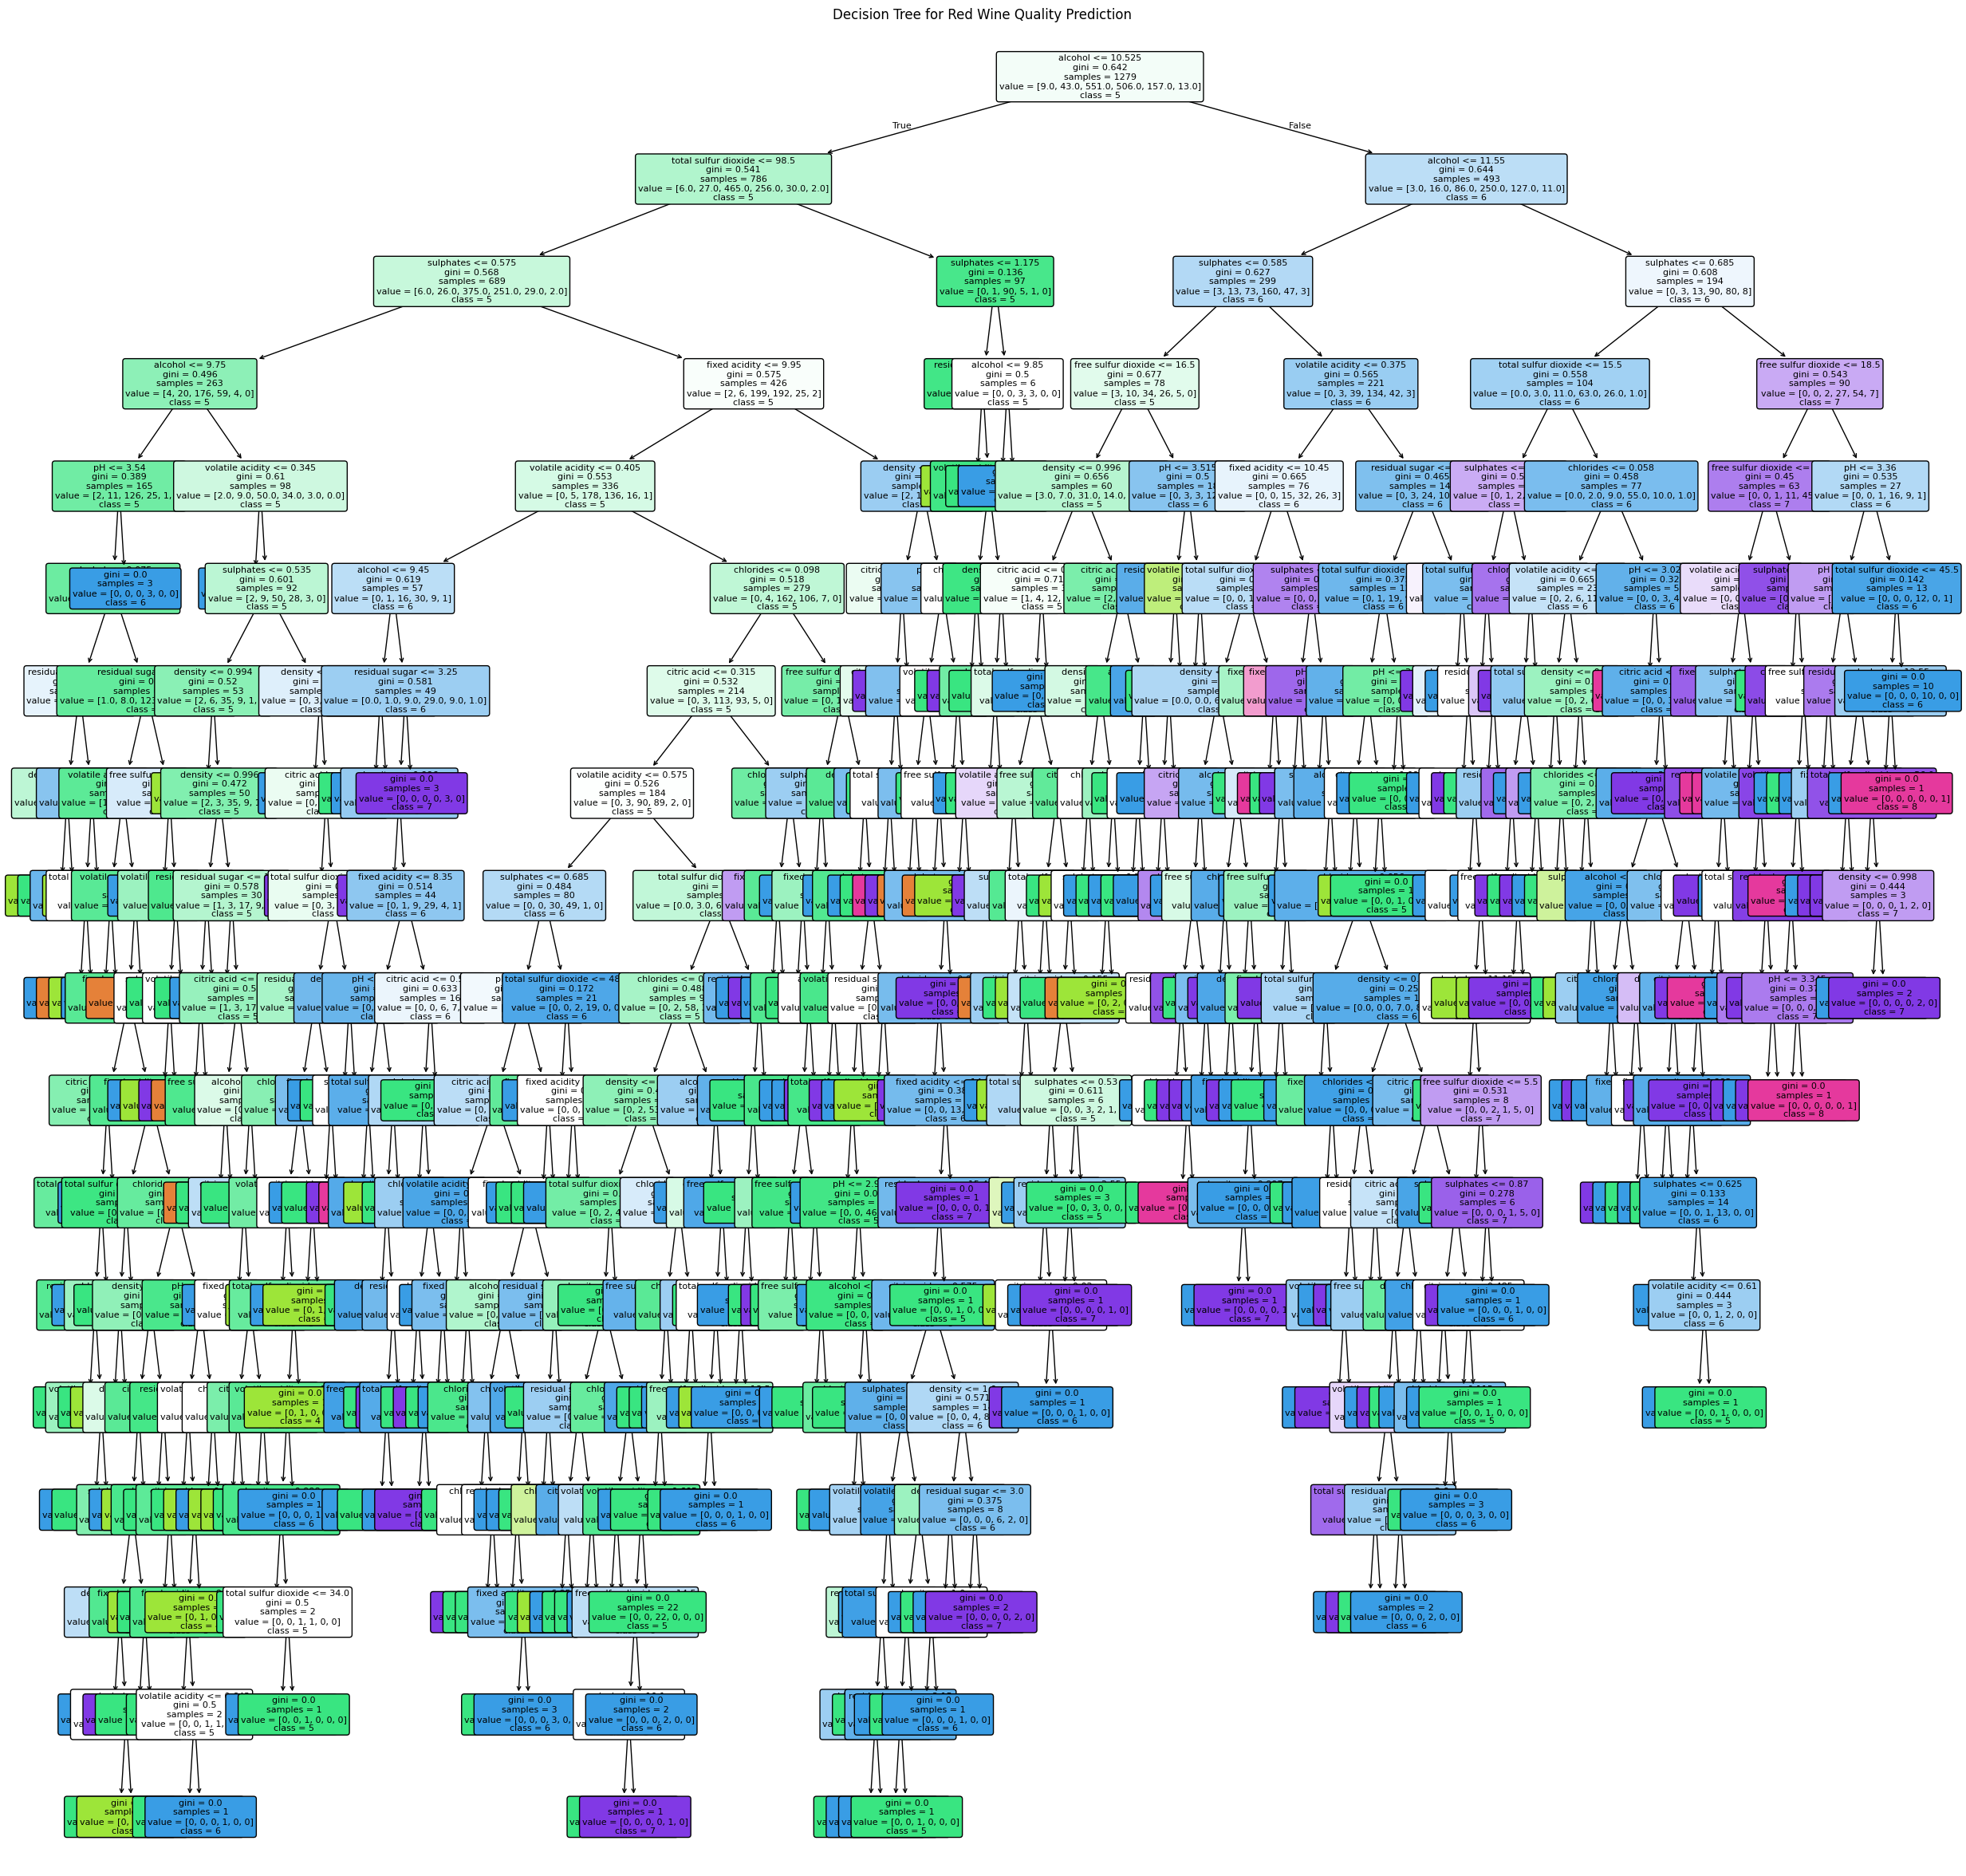

In [13]:
# Initialize and train the Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model (optional, but good practice)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2f}")

# Visualize the Decision Tree
plt.figure(figsize=(30, 30))
plot_tree(model, 
          feature_names=features.columns,  
          class_names=[str(c) for c in model.classes_],
          filled=True, 
          rounded=True, 
          fontsize=8)
plt.title("Decision Tree for Red Wine Quality Prediction")
plt.show()

- Yikes. Model Accuracy: 0.56.

- The root node is the very first box at the top of the tree. It contains the initial split rule that divides the entire dataset. In this dataset, the root node's split is based on the `volatile acidity` feature.
- Understand the Components of a Node Box
    - Each box in the tree is a node. It provides key information about the data at that specific point in the decision-making process.
        - **Split Rule**: The first line (Example: `alcohol` <= 10.525) is the decision rule. This is the condition the model uses to split the data. Data points that satisfy the condition go to the left child node, and those that don't go to the right child node. Example: at the root node, if a wine has `alcohol` <= 10.525, you follow the left branch. If it has `alcohol` > 10.525, you follow the right branch.
        - **Gini**: The Gini impurity is a measure of how "pure" the node is. A Gini value of 0 means the node is perfectly pure, containing samples from only one class. A value of 0.5 means the data is perfectly mixed (e.g., 50% of one class, 50% of another). The model's goal is to find splits that reduce the Gini impurity. (Default mode is Gini, one can change to use MSE).
        - **Samples**: The number of training data points that have reached this node.
        - **Value**: This shows the count of samples for each class in the node. In this case, value = [1041, 381, 107] means there are 1041 samples of class 5, 381 of class 6, and 107 of class 7.
        - **Class**: The predicted class for the majority of the samples in that node. This is the final prediction if this node were a leaf node.

- Going down each box is similar in terms of making decisions per feature.

### Note - Low Model Accuracy
The accuracy of a single decision tree may not be sufficient for a complex dataset such as this especially when we have observed that **multicollinearity** is a topic of interest.

---

# Decision Tree for Regression

--- Final Model Performance Metrics ---
Validation MSE: 0.4942
Test MSE: 0.5407
Validation RMSE: 0.7030
Test RMSE: 0.7353
Validation MAE: 0.5147
Test MAE: 0.5367
Validation R-squared: 0.6305
Test R-squared: 0.5897


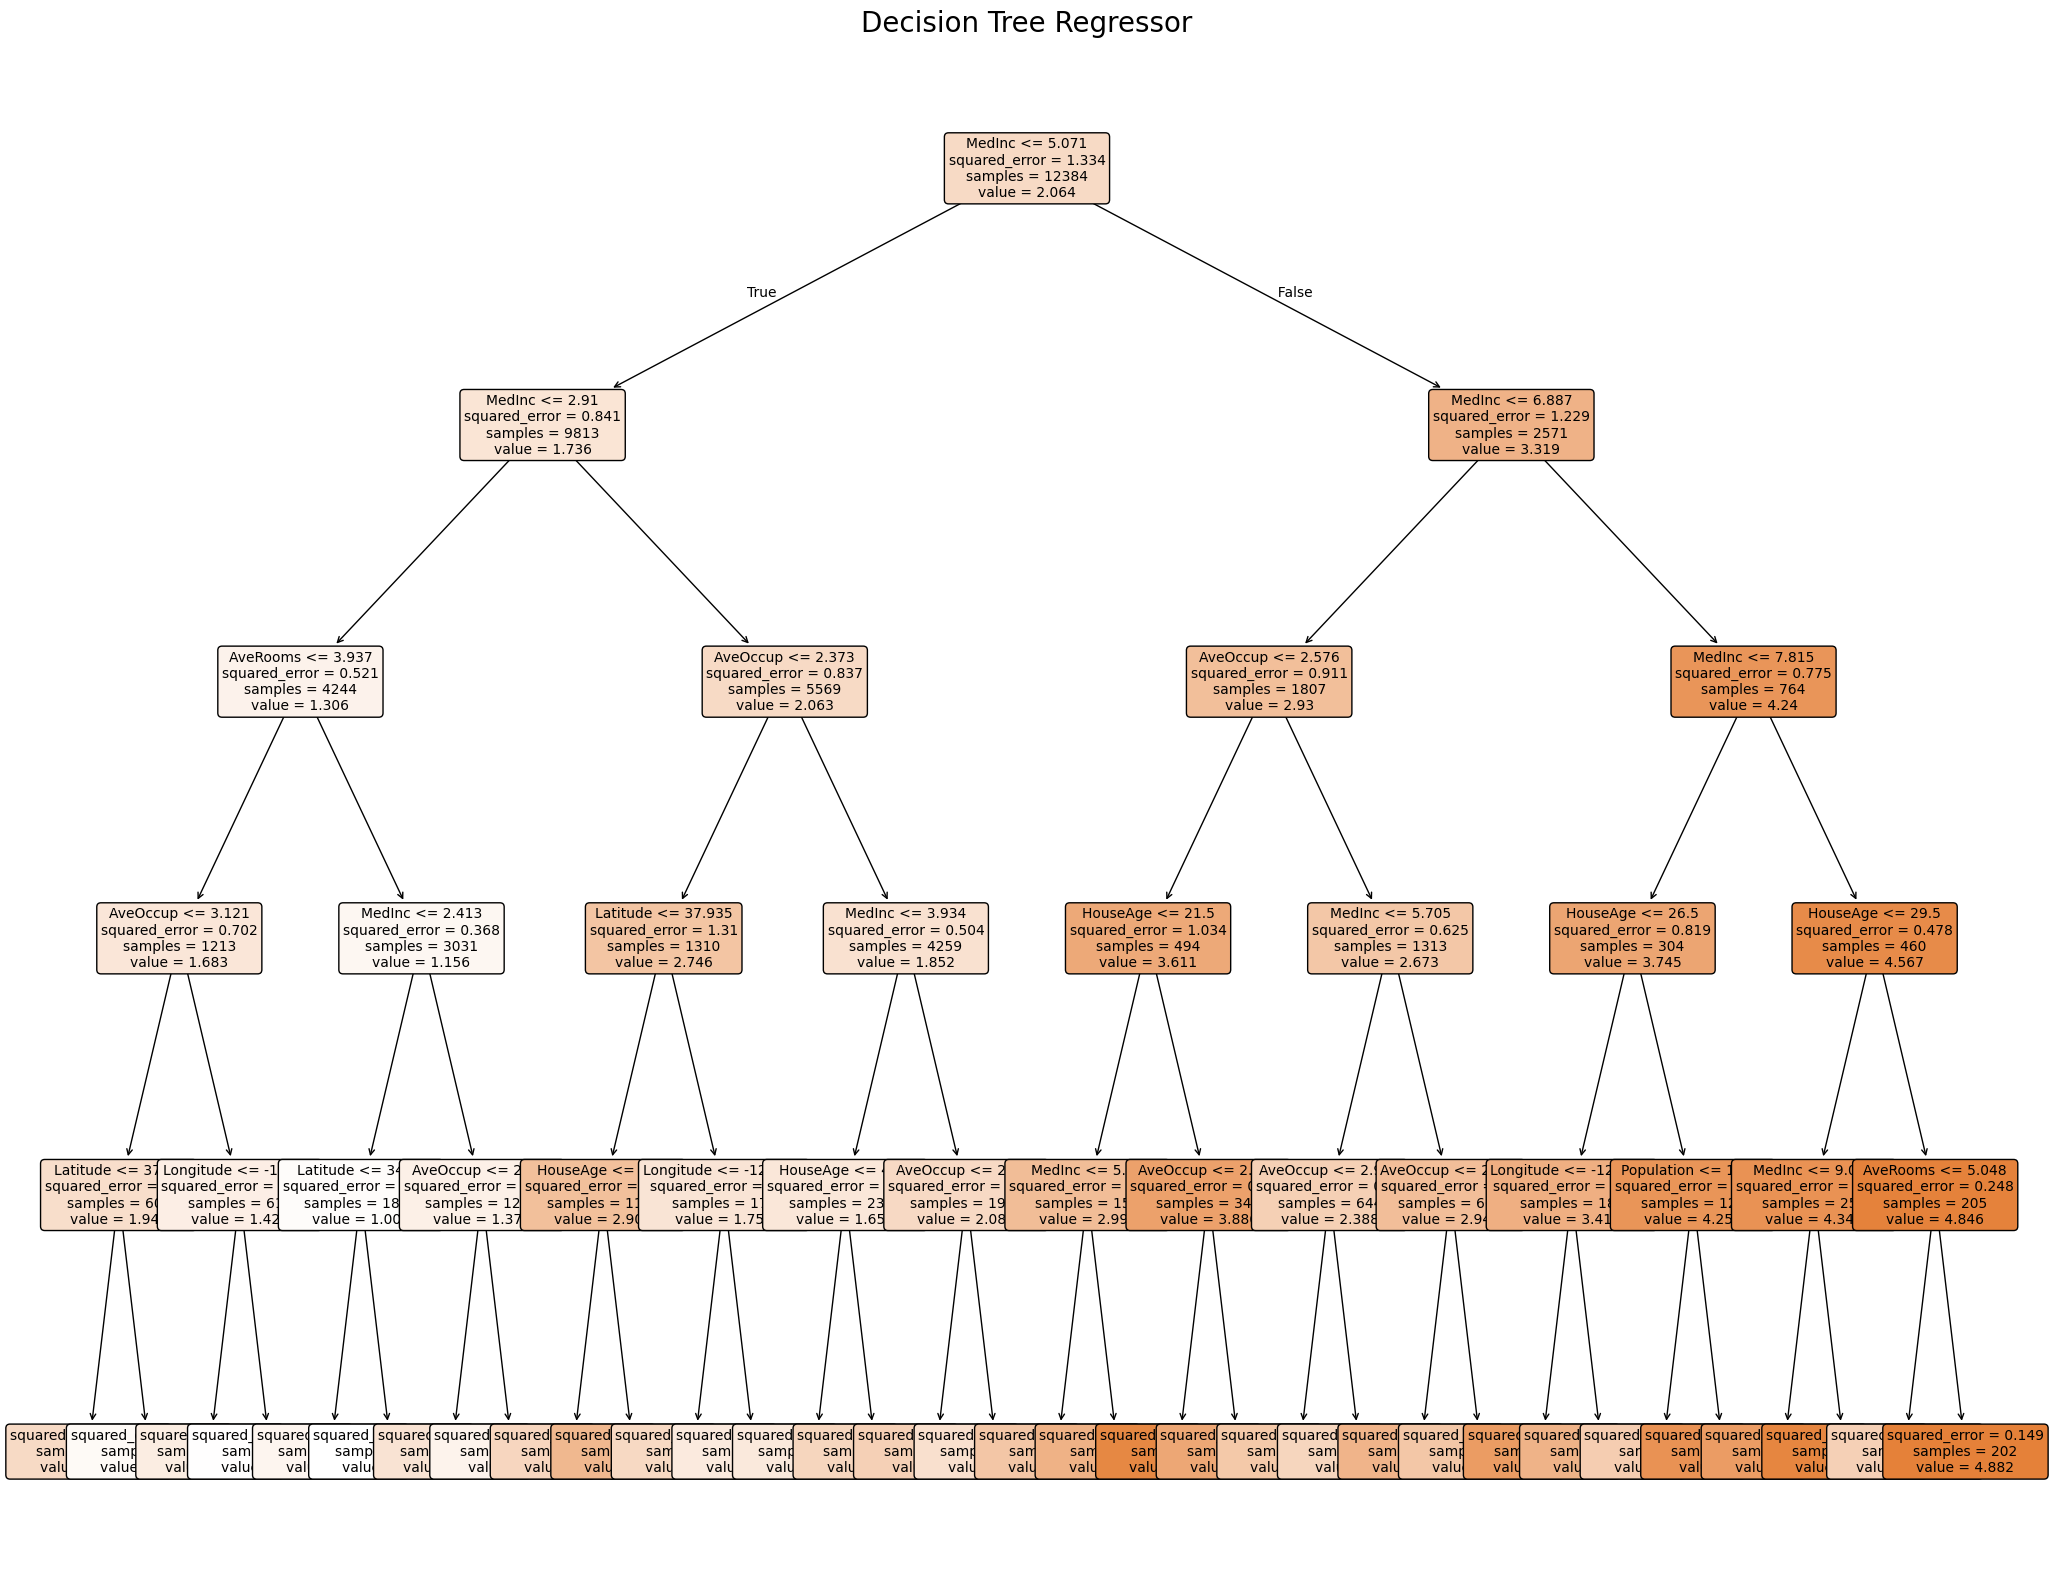

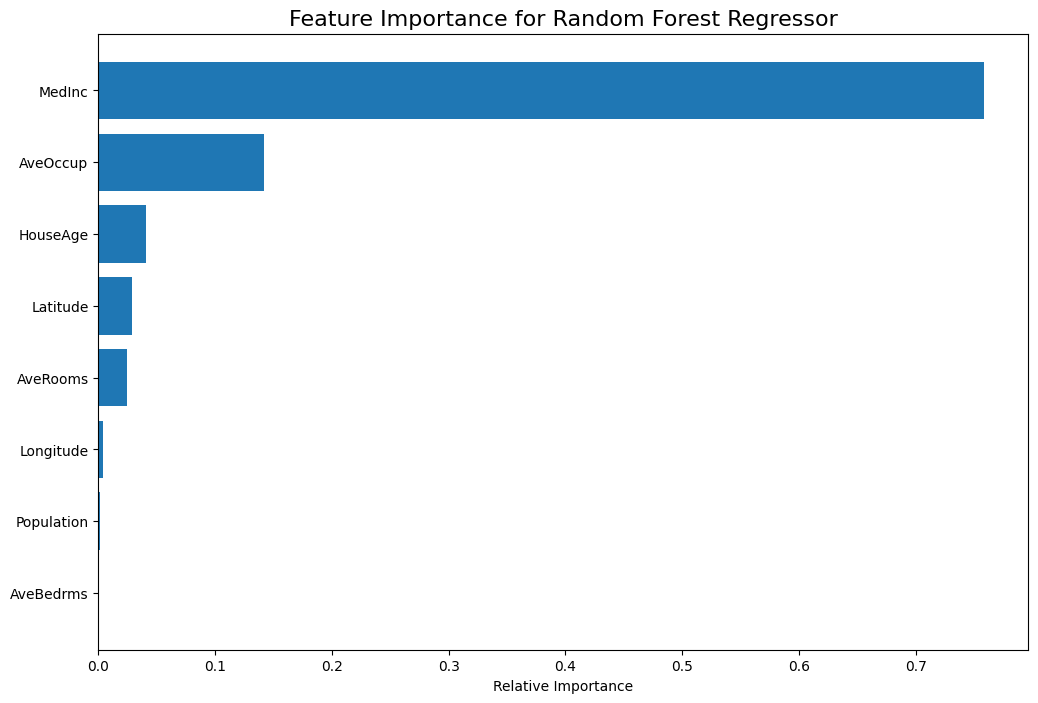

In [19]:

data = fetch_california_housing()
X, y = data.data, data.target

# Split data into training, testing, and validation sets
# 60% training, 20% validation, 20% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(max_depth=5, random_state=1234)
model.fit(X_train, y_train)

# Make predictions on the validation and test sets
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# Calculate final metrics
val_mse = mean_squared_error(y_val, val_pred)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

test_mse = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

# --- Print Final Metrics ---
print("--- Final Model Performance Metrics ---")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Validation R-squared: {val_r2:.4f}")
print(f"Test R-squared: {test_r2:.4f}")

# --- Plot the final decision tree ---
plt.figure(figsize=(25, 20))
plot_tree(
    model,
    feature_names=data.feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor", fontsize=20)
plt.show()

# --- Plot Feature Importance ---
importances = model.feature_importances_
sorted_indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importance for Random Forest Regressor', fontsize=16)
plt.show()


--- 
# Random Forest

- A random forest is a more robust and powerful machine learning algorithm that is built on the concept of decision trees.
- It's an **ensemble learning** method, meaning it combines the predictions of multiple individual models to produce a single, more accurate result. 
- As the name suggests, it creates a "forest" of many decision trees.
- Summary of How it works:
    - Bootstrap Sampling (Bagging): 
        - Creates multiple random subsets of the original data. 
        - This is done with replacement, meaning some data points may be used multiple times in a single subset, while others may not be used at all. 
        - This ensures each tree is trained on a slightly different dataset.
    -  Random Feature Selection: 
        - For each tree, it selects a random subset of features to consider when making a split.
        - This prevents a single, highly influential feature from dominating all the trees, which helps to create diverse and uncorrelated trees.
    - Aggregation: 
        - For a classification problem, the final prediction is determined by a majority vote from all the individual trees. 
        - For a regression problem, it's the average of all the trees' predictions.


## Random Forest for Classification

### Breast Cancer Dataset

In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
 
# Split the data into 60% training and 40% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)

# Split the temporary data into 50% validation and 50% testing
# This results in a 20% validation set and 20% test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# Initialize and train the Decision Tree model on the training data
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model on the validation set
val_predictions = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {val_accuracy:.2f}")

# Evaluate the model on the final, unseen test set
test_predictions = model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test Accuracy: {test_accuracy:.2f}")

Validation Accuracy: 0.89
Test Accuracy: 0.94


Reminder: A single Decision tree:  
- Validation Accuracy: 0.88
- Test Accuracy: 0.89

## Random Forest for Regressor

--- Final Model Performance Metrics ---
Validation MSE: 0.4277
Test MSE: 0.4674
Validation RMSE: 0.6540
Test RMSE: 0.6837
Validation MAE: 0.4781
Test MAE: 0.4974
Validation R-squared: 0.6803
Test R-squared: 0.6453


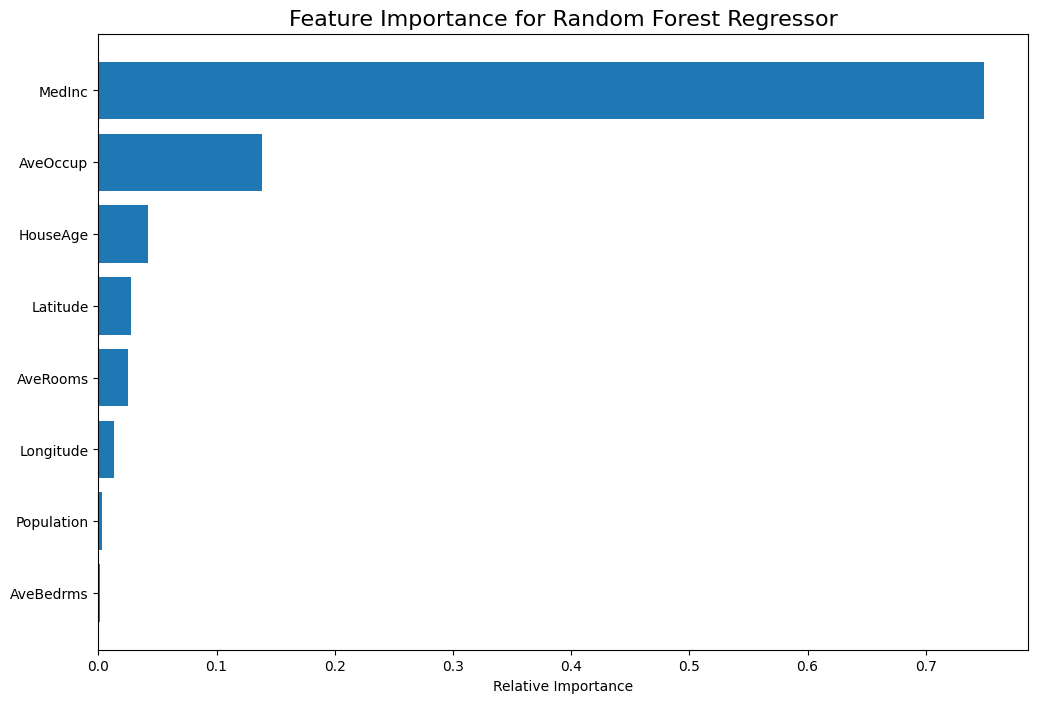

In [ ]:
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# Split data into training, testing, and validation sets
# 60% training, 20% validation, 20% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=1234
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1234
)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1234)
model.fit(X_train, y_train)

# Make predictions on the validation and test sets
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# Calculate final metrics
val_mse = mean_squared_error(y_val, val_pred)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

test_mse = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

# --- Print Final Metrics ---
print("--- Final Model Performance Metrics ---")
print(f"Validation MSE: {val_mse:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Validation MAE: {val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Validation R-squared: {val_r2:.4f}")
print(f"Test R-squared: {test_r2:.4f}")

# --- Plot Feature Importance ---
importances = model.feature_importances_
sorted_indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importance for Random Forest Regressor', fontsize=16)
plt.show()

Reminder: Decision Tree: 
- Validation MSE: 0.4942
- Test MSE: 0.5407
- Validation RMSE: 0.7030
- Test RMSE: 0.7353
- Validation MAE: 0.5147
- Test MAE: 0.5367
- Validation R-squared: 0.6305
- Test R-squared: 0.5897

---
# Summary of Random Forest
- Training: Parallel (each tree is independent)
- Ensemble Method: Bagging Aggregation
- Goal: Reduce variance, robust
- Speed: Fast due to parallelization
- Robustness: Robust to noisy data and outlier
- Overfitting: Less prone to overfitting
- Interpretability: Generally more interpretable
- Fine-tuning: Not as much required 